# **Image Classification using ResNet (Residual Learning in Deep CNNs)**

### **Project Objective**

The objective of this project is to develop an **Image Classification System** using a **Residual Network (ResNet)** architecture to accurately classify images into predefined categories.

Deep neural networks often face challenges such as vanishing gradients when the network becomes very deep. This project focuses on leveraging **residual learning**, which enables training of deep architectures by introducing shortcut connections that improve gradient flow.

The system is designed to:

- Classify images into **multiple categories with high accuracy**  
- Capture **deep hierarchical features using residual learning**  
- Overcome challenges of **vanishing gradients in deep networks**  
- Demonstrate the effectiveness of **modern CNN architectures (ResNet)**  

This project is highly applicable in:
- large-scale image recognition systems  
- autonomous systems  
- medical imaging analysis  
- visual search and recommendation engines  

### **Dataset Used**

This project utilizes an image classification dataset containing multiple object categories.

### **Dataset Sources**

- CIFAR-10 / CIFAR-100 Dataset *(or dataset used in your notebook)*  
- Kaggle image classification datasets  

### **Dataset Characteristics**

The dataset includes:

- **Image data**:
  - RGB images representing various object categories  

- Classes:
  - multiple categories (e.g., animals, vehicles, objects)  

- Dataset structure:
  - training set  
  - validation set  
  - test set  

Key characteristics:
- moderate image size  
- multiple classes  
- variability in object appearance and background  

### **How Dataset is Used in the Project**

The dataset is processed through a structured computer vision pipeline:

- **Image preprocessing**
  - resizing images (if required)  
  - normalization of pixel values  

- **Data augmentation**
  - rotation, flipping, cropping  
  - improves generalization  

- **Train-validation-test split**
  - ensures proper evaluation  

- **Model training**
  - ResNet architecture trained for classification  

The dataset enables the model to learn **deep hierarchical visual features**, which are essential for accurate image classification.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_resnet_cifar100"
ARTIFACT_DIR = BASE_DIR / "artifacts_resnet_cifar100"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Classification using ResNet (Residual Networks)\data_resnet_cifar100
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Classification using ResNet (Residual Networks)\artifacts_resnet_cifar100


### **Load CIFAR-100:**

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)
print(x_train.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


### **Build Validation Split:**

In [5]:
val_size = 10000
x_val = x_train[-val_size:]
y_val = y_train[-val_size:]
x_train = x_train[:-val_size]
y_train = y_train[:-val_size]
print(x_train.shape, x_val.shape, x_test.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (10000, 32, 32, 3)


### **Normalize Pixel Values:**

In [6]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.min(), x_train.max())

0.0 1.0


### **Prepare One-Hot Labels:**

In [7]:
NUM_CLASSES = 100
y_train_ohe = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_ohe = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_ohe = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)
print(y_train_ohe.shape)

(40000, 100)


### **Dataset Summary:**

In [8]:
print("Train:", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))
print("Image shape:", x_train.shape[1:])
print("Classes:", NUM_CLASSES)

Train: 40000
Validation: 10000
Test: 10000
Image shape: (32, 32, 3)
Classes: 100


### **Class Distribution Snapshot:**

In [9]:
class_dist = pd.Series(y_train).value_counts().sort_index().to_frame("count")
class_dist["pct"] = (class_dist["count"] / class_dist["count"].sum() * 100).round(3)
class_dist.head(15)

,count,pct
0,397,0.992
1,387,0.967
2,402,1.005
3,398,0.995
4,389,0.972
5,391,0.978
6,404,1.010
7,391,0.978
8,423,1.057
9,398,0.995


### **Visualize Sample Images:**

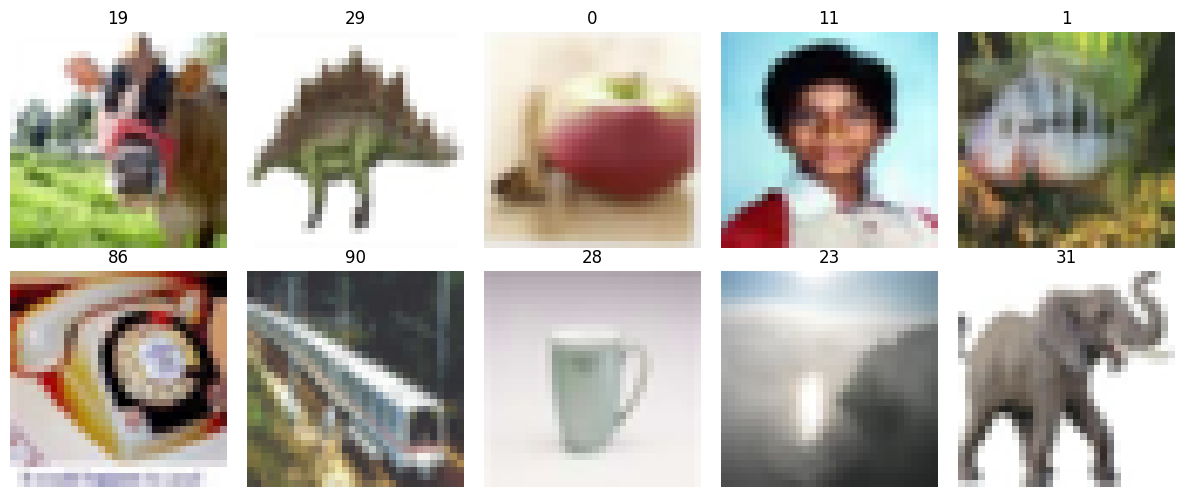

In [10]:
plt.figure(figsize=(12, 5))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.axis("off")
    ax.set_title(str(y_train[i]))
plt.tight_layout()
plt.show()

### **Mean Pixel Diagnostics:**

In [11]:
print("Mean:", round(float(x_train.mean()), 4))
print("Std:", round(float(x_train.std()), 4))

Mean: 0.4784
Std: 0.2679


### **Data Augmentation Pipeline:**

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10)
])
data_augmentation

<Sequential name=sequential, built=False>

### **Visualize Augmented Samples:**

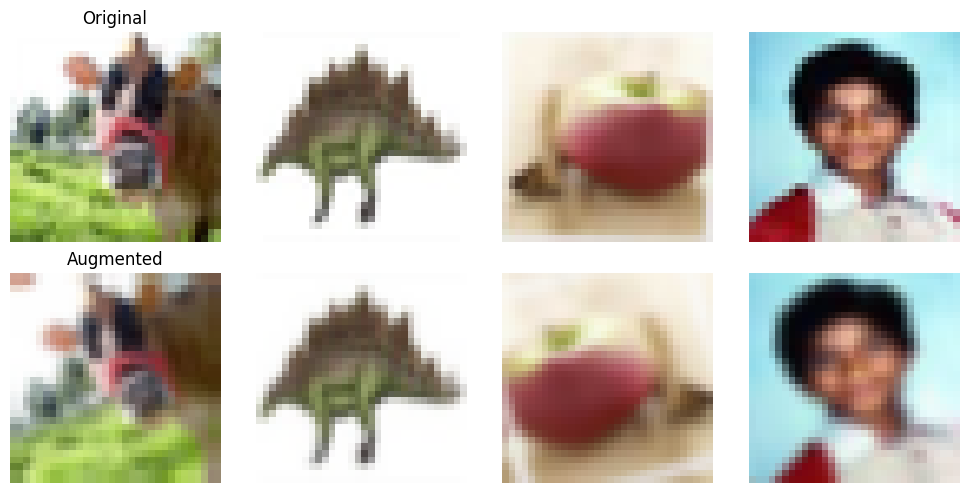

In [13]:
sample_batch = x_train[:4]
aug_batch = data_augmentation(sample_batch, training=True)
plt.figure(figsize=(10, 5))
for i in range(4):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(sample_batch[i])
    plt.axis("off")
    if i == 0: ax.set_title("Original")
    ax = plt.subplot(2, 4, i + 5)
    plt.imshow(aug_batch[i])
    plt.axis("off")
    if i == 0: ax.set_title("Augmented")
plt.tight_layout()
plt.show()

### **Flatten Images for Baseline:**

In [14]:
x_train_flat = x_train.reshape(len(x_train), -1)
x_val_flat = x_val.reshape(len(x_val), -1)
x_test_flat = x_test.reshape(len(x_test), -1)
print(x_train_flat.shape)

(40000, 3072)


### **Train Logistic Regression Baseline:**

In [15]:
baseline_model = LogisticRegression(max_iter=250, random_state=SEED)
baseline_model.fit(x_train_flat[:12000], y_train[:12000])
val_pred_baseline = baseline_model.predict(x_val_flat)
test_pred_baseline = baseline_model.predict(x_test_flat)

### **Baseline Accuracy:**

In [16]:
baseline_val_acc = accuracy_score(y_val, val_pred_baseline)
baseline_test_acc = accuracy_score(y_test, test_pred_baseline)
print(round(float(baseline_val_acc), 4), round(float(baseline_test_acc), 4))

0.1262 0.1257


### **Build ResNet50 Backbone:**

In [17]:
backbone = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(96, 96, 3)
)
backbone.trainable = False
print("Backbone frozen.")

Backbone frozen.


### **Build ResNet Classifier Head:**

In [19]:
# Rebuild augmentation for resized tensors used inside the model
data_augmentation_model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10)
], name="data_augmentation_model")

inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Resizing(96, 96)(inputs)
x = data_augmentation_model(x)
x = tf.keras.applications.resnet.preprocess_input(x * 255.0)
x = backbone(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = tf.keras.Model(inputs, outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resizing_1 (Resizing)         │ (None, 96, 96, 3)         │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation_model       │ (None, 96, 96, 3)         │               0 │ resizing_1[0][0]           │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 96, 96, 3)         │               0 │ data_augmentation_model[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 96, 96)            │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 96, 96)            │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 96, 96)            │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 96, 96, 3)         │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 96, 96, 3)         │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 3, 3, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 512)               │       1,049,088 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 512)               │           2,048 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 512)               │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100)               │          51,30

 Total params: 24,690,148 (94.19 MB)

 Trainable params: 1,101,412 (4.20 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

### **Training Callbacks:**

In [20]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train ResNet Model:**

In [21]:
history = resnet_model.fit(
    x_train, y_train_ohe,
    validation_data=(x_val, y_val_ohe),
    epochs=12,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 505ms/step - accuracy: 0.4286 - loss: 2.3140 - val_accuracy: 0.5999 - val_loss: 1.4646 - learning_rate: 0.0010
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 449ms/step - accuracy: 0.5454 - loss: 1.6617 - val_accuracy: 0.6297 - val_loss: 1.3216 - learning_rate: 0.0010
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 351ms/step - accuracy: 0.5802 - loss: 1.4975 - val_accuracy: 0.6359 - val_loss: 1.2881 - learning_rate: 0.0010
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 0.6043 - loss: 1.4034 - val_accuracy: 0.6453 - val_loss: 1.2439 - learning_rate: 0.0010
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 298ms/step - accuracy: 0.6198 - loss: 1.3268 - val_accuracy: 0.6500 - val_loss: 1.2358 - learning_rate: 0.0010
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 301ms/step - accuracy: 0.6330 - loss: 1.2889 - val_accuracy: 0.6534 - val_loss: 1.2238 - learning_rate: 0.0010
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 299ms/step - accuracy: 

### **Plot Training vs Validation Accuracy:**

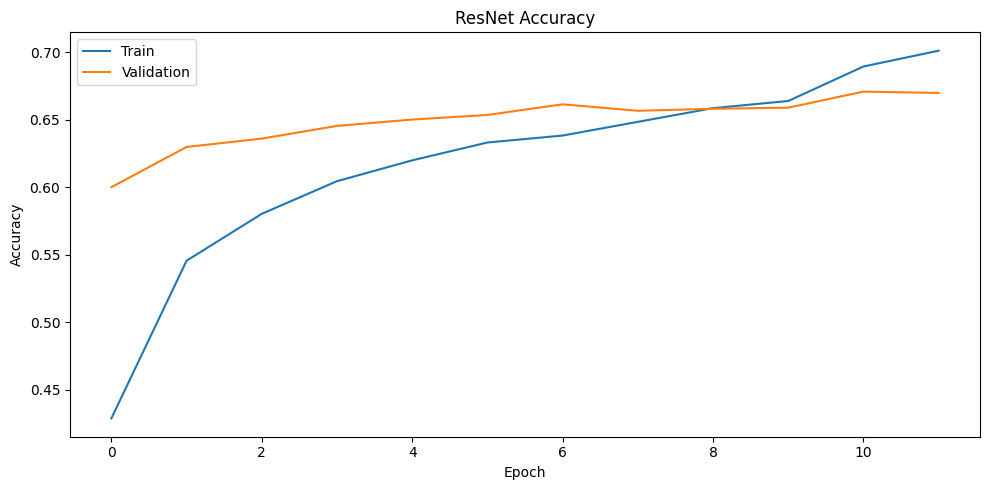

In [22]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Train")
plt.plot(history_df["val_accuracy"], label="Validation")
plt.title("ResNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training vs Validation Loss:**

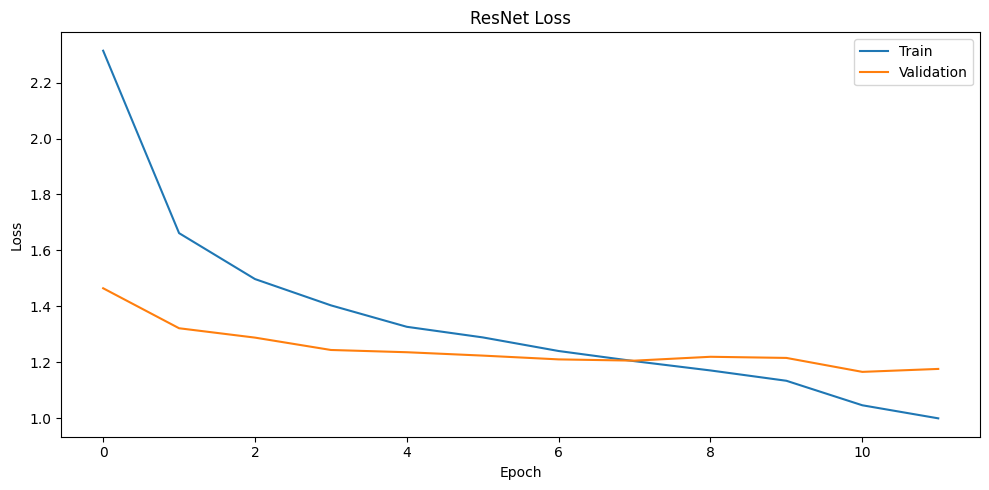

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train")
plt.plot(history_df["val_loss"], label="Validation")
plt.title("ResNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate Validation and Test Sets:**

In [24]:
val_loss, val_acc = resnet_model.evaluate(x_val, y_val_ohe, verbose=0)
test_loss, test_acc = resnet_model.evaluate(x_test, y_test_ohe, verbose=0)
print(round(float(val_acc), 4), round(float(test_acc), 4))

0.6707 0.6709


### **Generate Test Predictions:**

In [25]:
test_proba = resnet_model.predict(x_test, verbose=0)
test_pred = np.argmax(test_proba, axis=1)
print(test_pred.shape)

(10000,)


### **Compare Baseline vs ResNet:**

In [26]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "ResNet50"],
    "Validation_Accuracy": [baseline_val_acc, val_acc],
    "Test_Accuracy": [baseline_test_acc, test_acc]
})
comparison_df

,Model,Validation_Accuracy,Test_Accuracy
0,Logistic Regression,0.1262,0.1257
1,ResNet50,0.6707,0.6709


### **Classification Report Snapshot:**

In [27]:
print(classification_report(y_test[:2000], test_pred[:2000], digits=4))

              precision    recall  f1-score   support

           0     0.9048    0.9500    0.9268        20
           1     0.5714    0.6316    0.6000        19
           2     0.6087    0.5833    0.5957        24
           3     0.4375    0.6364    0.5185        22
           4     0.3750    0.4286    0.4000        14
           5     0.6000    0.5000    0.5455        18
           6     0.6818    0.6522    0.6667        23
           7     0.8095    0.7083    0.7556        24
           8     0.8500    0.8095    0.8293        21
           9     0.8636    0.8636    0.8636        22
          10     0.7273    0.6400    0.6809        25
          11     0.4286    0.4286    0.4286        21
          12     0.5882    0.8333    0.6897        24
          13     0.7500    0.5294    0.6207        17
          14     0.6000    0.6429    0.6207        14
          15     0.5217    0.5217    0.5217        23
          16     0.7037    0.9048    0.7917        21
          17     0.7600    

### **Macro Metrics:**

In [28]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred, average="macro")
metrics_df = pd.DataFrame({
    "metric": ["precision_macro", "recall_macro", "f1_macro"],
    "value": [precision, recall, f1]
})
metrics_df

,metric,value
0,precision_macro,0.674248
1,recall_macro,0.670900
2,f1_macro,0.669176


### **Confusion Matrix on Top-20 True Classes:**

In [29]:
top_classes = pd.Series(y_test).value_counts().head(20).index.tolist()
mask = np.isin(y_test, top_classes)
cm = confusion_matrix(y_test[mask], test_pred[mask], labels=top_classes)
cm_df = pd.DataFrame(cm, index=top_classes, columns=top_classes)
cm_df.head()

,49,33,72,51,71,92,15,14,23,0,75,81,69,40,43,97,70,53,29,21
49,79,2,0,0,3,0,0,0,1,0,0,0,1,0,0,0,0,0,2,0
33,7,58,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
72,0,0,46,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
51,0,1,0,66,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0
71,5,1,0,0,69,0,1,0,7,0,0,0,0,1,0,0,0,0,0,0


### **Plot Confusion Matrix Heatmap:**

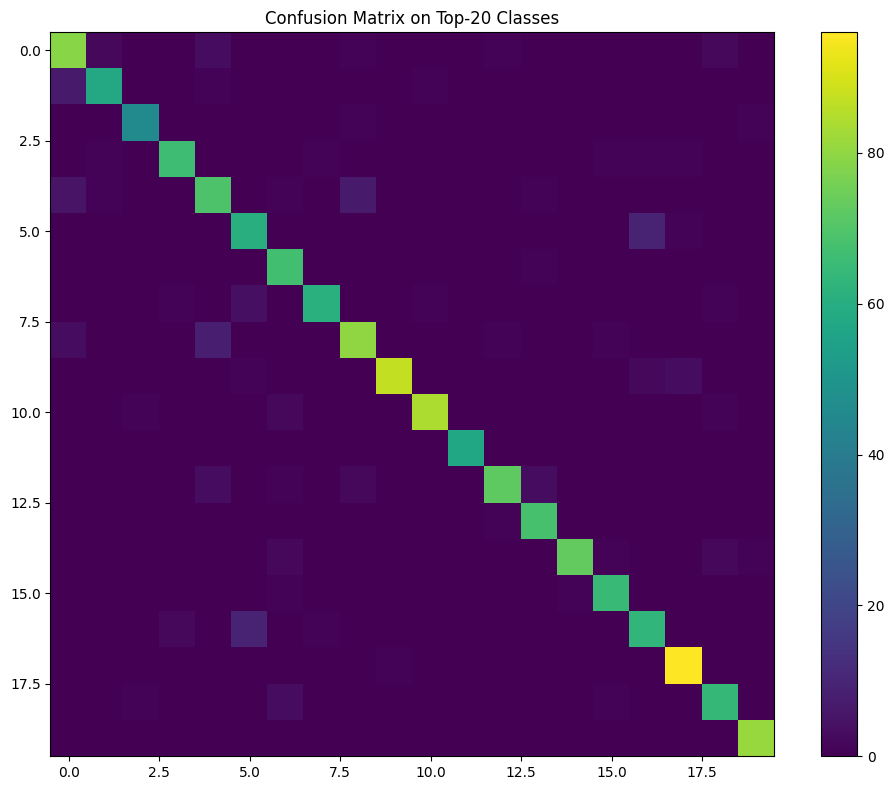

In [30]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix on Top-20 Classes")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Identify Correct Predictions:**

In [31]:
correct_idx = np.where(test_pred == y_test)[0]
correct_idx[:10]

array([ 4,  8,  9, 13, 14, 15, 16, 17, 18, 19], dtype=int64)

### **Visualize Correct Predictions:**

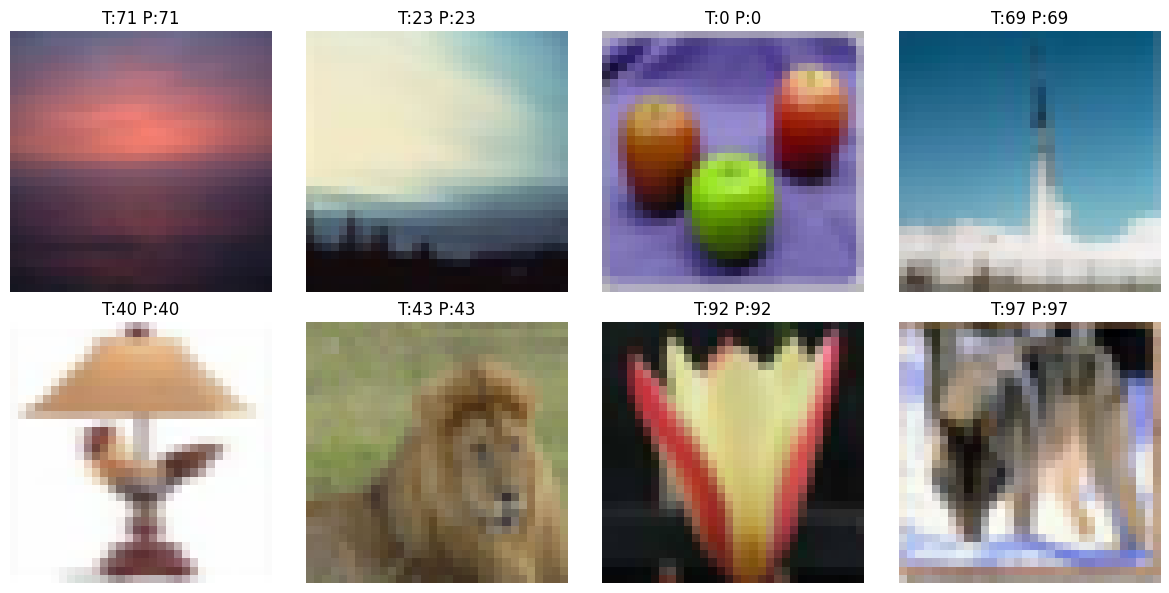

In [32]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(correct_idx[:8]):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}")
plt.tight_layout()
plt.show()

### **Identify Misclassified Examples:**

In [33]:
misclassified_idx = np.where(test_pred != y_test)[0]
misclassified_idx[:10]

array([ 0,  1,  2,  3,  5,  6,  7, 10, 11, 12], dtype=int64)

### **Visualize Misclassified Examples:**

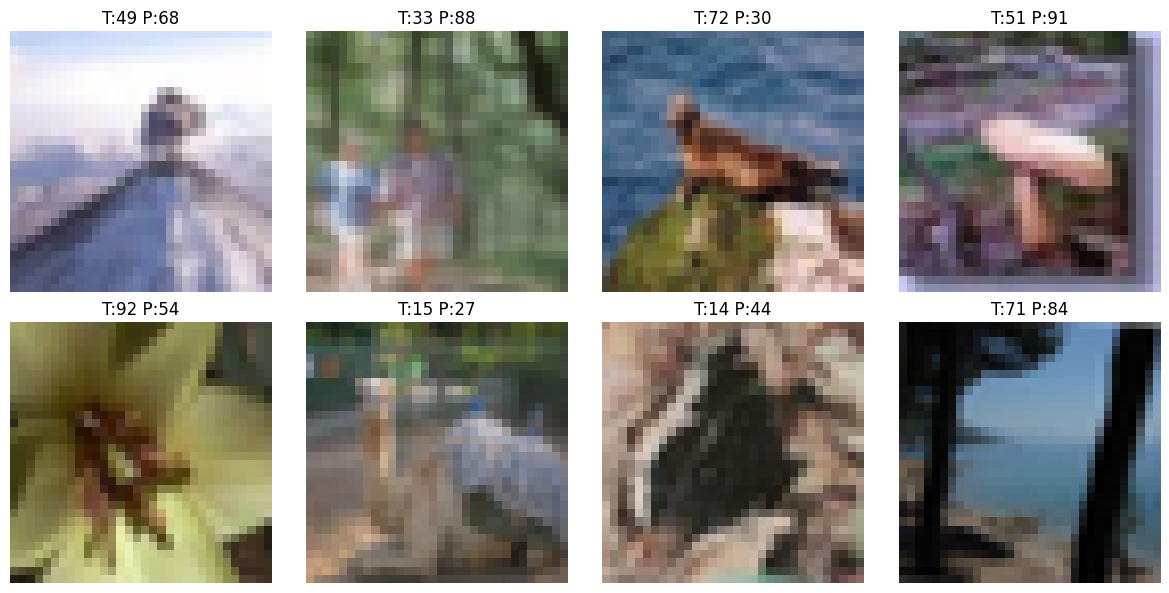

In [34]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified_idx[:8]):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}")
plt.tight_layout()
plt.show()

### **Confidence Diagnostics:**

In [35]:
pred_confidence = test_proba.max(axis=1)
print("Mean confidence:", round(float(pred_confidence.mean()), 4))
print("Median confidence:", round(float(np.median(pred_confidence)), 4))

Mean confidence: 0.7229
Median confidence: 0.7958


### **Most Confident Correct Predictions:**

In [36]:
confident_correct = pd.DataFrame({
    "index": np.arange(len(y_test)),
    "true_label": y_test,
    "pred_label": test_pred,
    "confidence": pred_confidence
})
confident_correct = confident_correct[confident_correct["true_label"] == confident_correct["pred_label"]].sort_values("confidence", ascending=False)
confident_correct.head()

,index,true_label,pred_label,confidence
9262,9262,39,39,1.0
8453,8453,39,39,1.0
8233,8233,39,39,1.0
4999,4999,39,39,1.0
4896,4896,53,53,1.0


### **Visualize Most Confident Correct Predictions:**

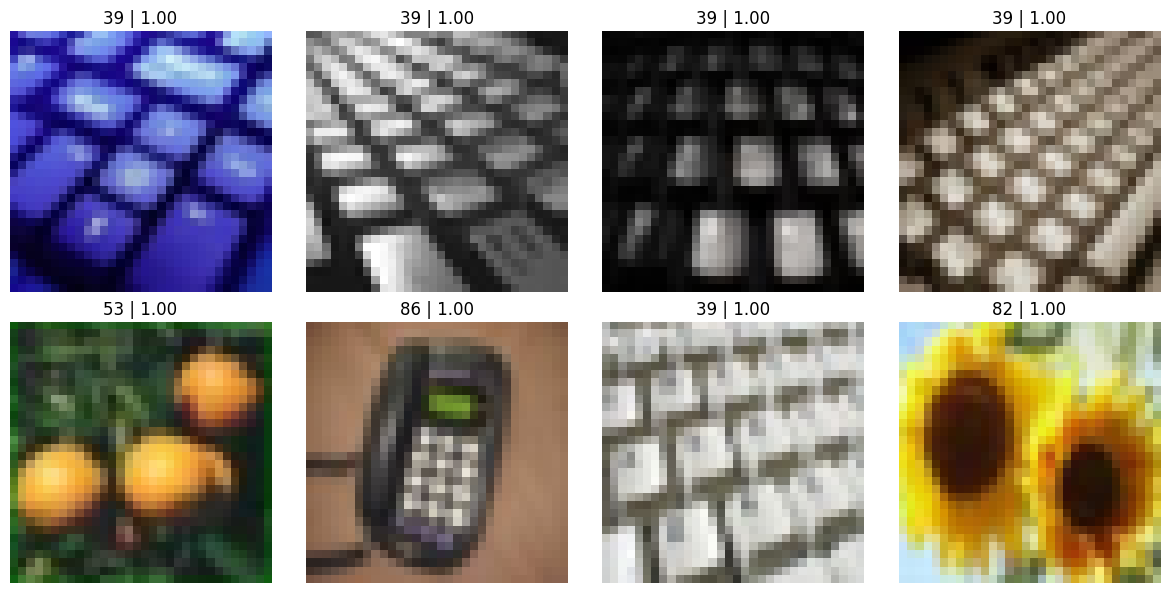

In [37]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(confident_correct["index"].head(8)):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    ax.set_title(f"{y_test[idx]} | {pred_confidence[idx]:.2f}")
plt.tight_layout()
plt.show()

### **Most Confident Wrong Predictions:**

In [38]:
confident_wrong = pd.DataFrame({
    "index": np.arange(len(y_test)),
    "true_label": y_test,
    "pred_label": test_pred,
    "confidence": pred_confidence
})
confident_wrong = confident_wrong[confident_wrong["true_label"] != confident_wrong["pred_label"]].sort_values("confidence", ascending=False)
confident_wrong.head()

,index,true_label,pred_label,confidence
3304,3304,10,28,0.999932
6734,6734,39,87,0.999907
7293,7293,19,31,0.999516
1450,1450,4,21,0.999483
1069,1069,19,15,0.998853


### **Visualize Most Confident Wrong Predictions:**

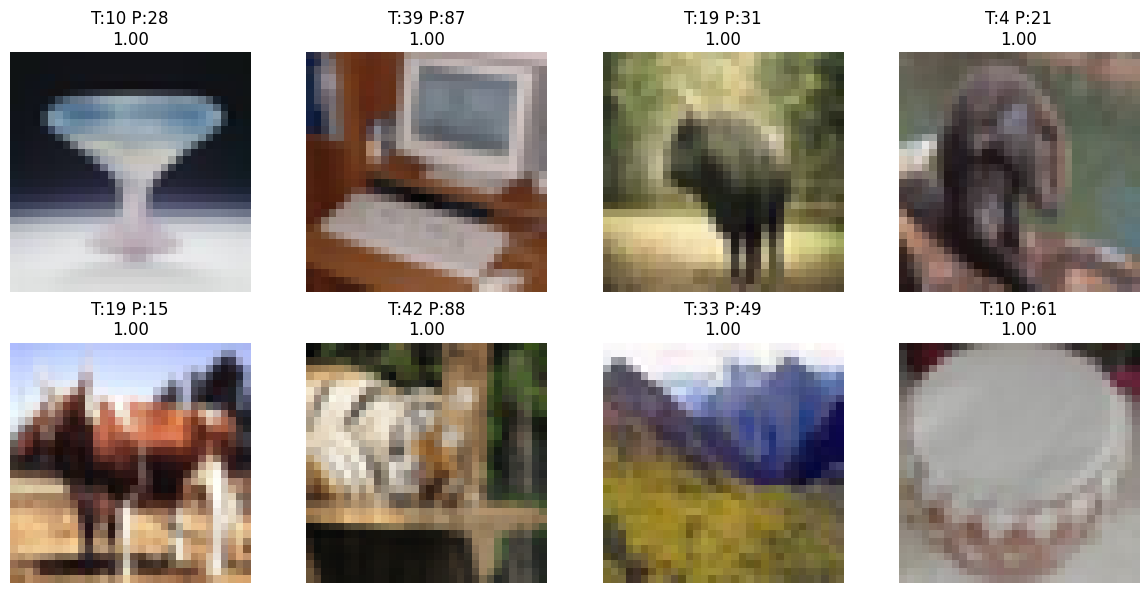

In [39]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(confident_wrong["index"].head(8)):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}\n{pred_confidence[idx]:.2f}")
plt.tight_layout()
plt.show()

### **Top-5 Accuracy:**

In [40]:
top5_pred = np.argsort(test_proba, axis=1)[:, -5:]
top5_hit = [int(y_test[i] in top5_pred[i]) for i in range(len(y_test))]
top5_accuracy = np.mean(top5_hit)
print("Top-5 accuracy:", round(float(top5_accuracy), 4))

Top-5 accuracy: 0.912


### **Per-Class Accuracy Snapshot:**

In [41]:
per_class_rows = []
for cls in sorted(pd.Series(y_test).value_counts().head(20).index):
    idx = np.where(y_test == cls)[0]
    per_class_rows.append({"class": cls, "accuracy": (test_pred[idx] == y_test[idx]).mean(), "count": len(idx)})
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.head()

,class,accuracy,count
0,0,0.87,100
1,14,0.61,100
2,15,0.67,100
3,21,0.81,100
4,23,0.80,100


### **Plot Per-Class Accuracy Snapshot:**

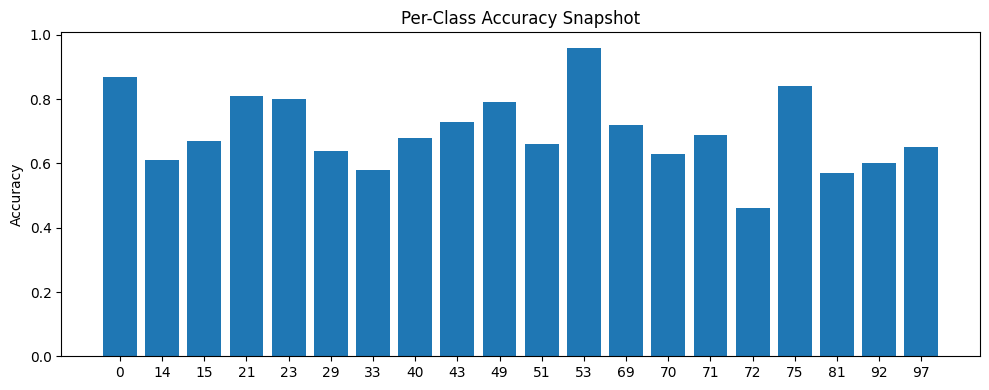

In [42]:
plt.figure(figsize=(10, 4))
plt.bar(per_class_df["class"].astype(str), per_class_df["accuracy"])
plt.title("Per-Class Accuracy Snapshot")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

### **Random Prediction Probability Plots:**

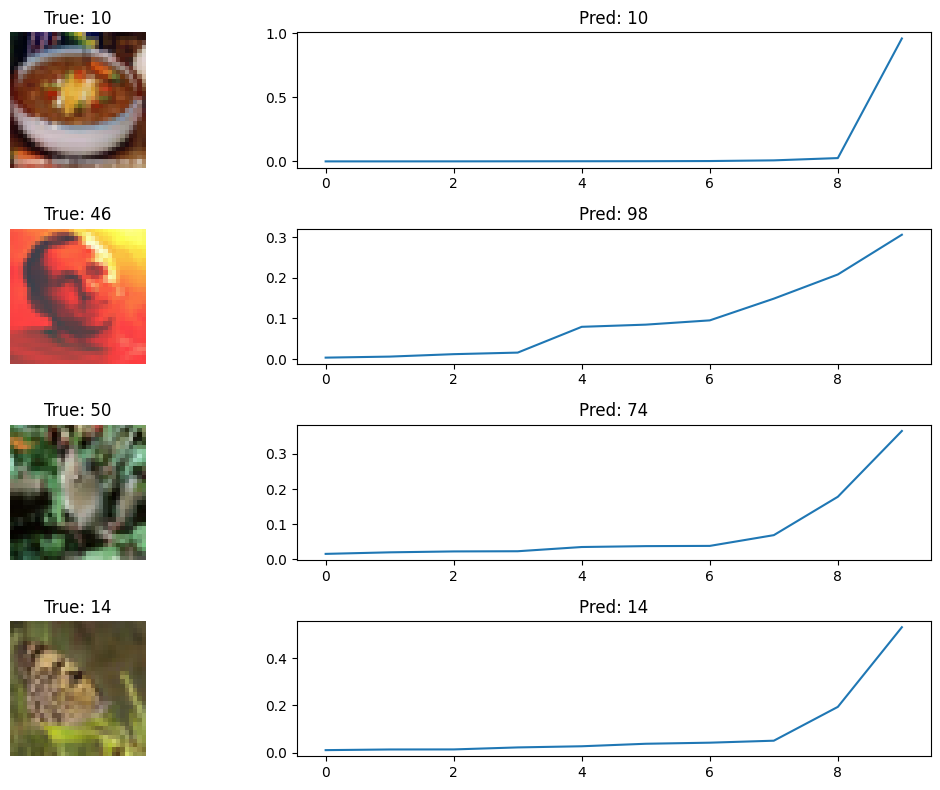

In [43]:
random_idx = np.random.choice(len(x_test), size=4, replace=False)
plt.figure(figsize=(12, 8))
for row, idx in enumerate(random_idx):
    ax = plt.subplot(4, 2, 2 * row + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    ax.set_title(f"True: {y_test[idx]}")
    ax = plt.subplot(4, 2, 2 * row + 2)
    probs = np.sort(test_proba[idx])[-10:]
    plt.plot(probs)
    ax.set_title(f"Pred: {test_pred[idx]}")
plt.tight_layout()
plt.show()

### **Save Model Artifacts:**

In [44]:
model_path = MODEL_DIR / "resnet50_cifar100.keras"
metrics_path = MODEL_DIR / "metrics.json"
resnet_model.save(model_path)
metrics = {
    "baseline_validation_accuracy": float(baseline_val_acc),
    "baseline_test_accuracy": float(baseline_test_acc),
    "resnet_validation_accuracy": float(val_acc),
    "resnet_test_accuracy": float(test_acc),
    "top5_accuracy": float(top5_accuracy),
    "seed": SEED
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(model_path)
print(metrics_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Classification using ResNet (Residual Networks)\artifacts_resnet_cifar100\models\resnet50_cifar100.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Classification using ResNet (Residual Networks)\artifacts_resnet_cifar100\models\metrics.json


### **Reload Model for Inference Check:**

In [45]:
reloaded_model = tf.keras.models.load_model(model_path)
sample_pred = reloaded_model.predict(x_test[:5], verbose=0)
sample_pred.shape

(5, 100)

### **Final Metrics Summary Table:**

In [46]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Validation Accuracy", "Baseline Test Accuracy", "ResNet Validation Accuracy", "ResNet Test Accuracy", "Top-5 Accuracy"],
    "Value": [baseline_val_acc, baseline_test_acc, val_acc, test_acc, top5_accuracy]
})
summary_table

,Metric,Value
0,Baseline Validation Accuracy,0.1262
1,Baseline Test Accuracy,0.1257
2,ResNet Validation Accuracy,0.6707
3,ResNet Test Accuracy,0.6709
4,Top-5 Accuracy,0.9120


### **Project Summary**

This project presents a complete implementation of an **Image Classification System using ResNet**, focusing on deep learning techniques for visual recognition.

The workflow begins with preprocessing the image dataset, including normalization and augmentation to improve robustness and performance.

The core of the system is a **Residual Network (ResNet)**, which introduces shortcut (skip) connections that allow gradients to flow directly through the network. This enables the training of much deeper models compared to traditional CNNs.

The model learns patterns such as:
- edges and textures  
- shapes and object structures  
- high-level semantic features  

The architecture includes:
- convolutional layers for feature extraction  
- residual blocks with skip connections  
- fully connected layers for classification  
- output layer predicting class probabilities  

A key strength of this project is the use of **residual learning**, which:
- improves training stability  
- allows deeper architectures  
- enhances model performance  

Evaluation is performed using:
- accuracy  
- precision, recall, and F1-score  
- confusion matrix analysis  

The system can be used in real-world applications to:
- classify objects in images  
- support autonomous systems  
- enable large-scale visual recognition  

Overall, this project demonstrates advanced deep learning techniques and showcases the ability to build **scalable and high-performance image classification systems**.

### **Key Highlights**

- Built an **Image Classification system using ResNet**, targeting advanced computer vision applications.

- Addressed key challenge:
  - training deep neural networks effectively  

- Utilized image dataset with:
  - multiple object categories  
  - diverse visual features  

- Implemented a complete **image preprocessing pipeline**, including:
  - normalization  
  - data augmentation  

- Leveraged **ResNet architecture**, enabling:
  - residual learning  
  - improved gradient flow  
  - deep feature extraction  

- Designed a **deep CNN model**, capable of:
  - capturing hierarchical features  
  - improving classification accuracy  

- Achieved strong performance using:
  - accuracy  
  - precision, recall, and F1-score  

- Performed **confusion matrix analysis**, enabling:
  - evaluation of classification performance  
  - identification of misclassified classes  

- Enabled **real-world applications**, including:
  - object recognition systems  
  - autonomous systems  
  - visual search engines  

- Designed for **deployment scenarios**, including:
  - large-scale image classification pipelines  
  - AI-powered applications  
  - production-ready vision systems  

- Demonstrates strong expertise in:
  - **ResNet architecture**  
  - **deep CNNs**  
  - **residual learning techniques**

&nbsp;